# Cross-domain evaluation — MLP (target scaling)

**Original execution record.** This notebook is the run that produced `results/cross_domain/target/MLP/`. Code and outputs are unchanged apart from English comments; paths refer to the original machine (`/opt/flids`).

Note: the scaler is refit on each target test set (`scaler.fit_transform(X_test)`), and the `train`/`val` dicts are loaded but unused. To re-run, use `python scripts/cross_domain_eval.py --arch MLP --scaling target`.

In [1]:
import pandas as pd
import numpy as np
import os
import gc

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model

# Scikit-learn
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# Used for the heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

used_model = "MLP"
directory = "/opt/flids"
save_dir = f"/opt/flids/tf/images/cross/{used_model}"
# Ensure save directory exists
os.makedirs(save_dir, exist_ok=True)

train_paths = [
    f"{directory}/data/split-data/NF-UNSW-NB15-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-BoT-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-ToN-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-CSE-CIC-IDS2018-v2_processed_val.csv"
]

val_paths = [
    f"{directory}/data/split-data/NF-UNSW-NB15-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-BoT-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-ToN-IoT-v2_processed_val.csv",
    f"{directory}/data/split-data/NF-CSE-CIC-IDS2018-v2_processed_val.csv"
]

test_paths = [
    f"{directory}/data/split-data/NF-UNSW-NB15-v2_processed_test.csv",
    f"{directory}/data/split-data/NF-BoT-IoT-v2_processed_test.csv",
    f"{directory}/data/split-data/NF-ToN-IoT-v2_processed_test.csv",
    f"{directory}/data/split-data/NF-CSE-CIC-IDS2018-v2_processed_test.csv"
]

model_paths = [
    f"{directory}/tf/models/base/hyperparameter-tuning/{used_model}_NFv2-UNSW-NB15_model.keras",
    f"{directory}/tf/models/base/hyperparameter-tuning/{used_model}_NFv2-BoT-IoT_model.keras",
    f"{directory}/tf/models/base/hyperparameter-tuning/{used_model}_NFv2-ToN-IoT_model.keras",
    f"{directory}/tf/models/base/hyperparameter-tuning/{used_model}_NFv2-CIC-2018_model.keras"
]
      
# These names are the keys of the train/val/test dicts
dataset_names = [
    "NFv2-UNSW-NB15",
    "NFv2-BoT-IoT",
    "NFv2-ToN-IoT",
    "NFv2-CIC-2018"
]

model_path = f"{directory}/tf/models/base/best/DNN_NFv2-UNSW-NB15_model.keras"
feature_to_remove = "attack"
train = {}
val = {}
test = {}

# QuantileTransformer with normal output (same scaler as in training)
scaler = QuantileTransformer(output_distribution='normal')

2025-03-26 06:31:46.424060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742970706.446291  292322 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742970706.452718  292322 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742970706.470064  292322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742970706.470081  292322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742970706.470083  292322 computation_placer.cc:177] computation placer alr

In [2]:

for i, name in enumerate(dataset_names):
    print(f"Loading dataset for: {name}")
    print("-" * 60)

    # =============== Load training split ===============
    df_train = pd.read_csv(train_paths[i])
    df_train.columns = df_train.columns.str.strip().str.lower()  # strip spaces + lower-case
    df_train.dropna(axis=0, inplace=True)                       # drop rows with missing values

    if "label" not in df_train.columns:
        raise ValueError(f"'label' column not found in {train_paths[i]}. "
                         f"Actual columns: {df_train.columns.tolist()}")

    y_train = df_train.pop("label").values  # pop the label column
    if feature_to_remove in df_train.columns:
        df_train.drop(columns=feature_to_remove, inplace=True)  # drop 'attack' if present
    X_train = df_train.values  # to numpy

    # =============== Load validation split ===============
    df_val = pd.read_csv(val_paths[i])
    df_val.columns = df_val.columns.str.strip().str.lower()
    df_val.dropna(axis=0, inplace=True)

    if "label" not in df_val.columns:
        raise ValueError(f"'label' column not found in {val_paths[i]}. "
                         f"Actual columns: {df_val.columns.tolist()}")

    y_val = df_val.pop("label").values
    if feature_to_remove in df_val.columns:
        df_val.drop(columns=feature_to_remove, inplace=True)
    X_val = df_val.values

    # =============== Load test split ===============
    df_test = pd.read_csv(test_paths[i])
    df_test.columns = df_test.columns.str.strip().str.lower()
    df_test.dropna(axis=0, inplace=True)

    if "label" not in df_test.columns:
        raise ValueError(f"'label' column not found in {test_paths[i]}. "
                         f"Actual columns: {df_test.columns.tolist()}")

    y_test = df_test.pop("label").values
    if feature_to_remove in df_test.columns:
        df_test.drop(columns=feature_to_remove, inplace=True)
    X_test = df_test.values

    # store in the global dicts
    train[name] = (X_train, y_train)
    val[name]   = (X_val, y_val)
    test[name]  = (X_test, y_test)

    # free temporaries
    del df_train, df_val, df_test, X_train, X_val, X_test
    del y_train, y_val, y_test
    gc.collect()

print("\nFinished loading all datasets.\n")

Loading dataset for: NFv2-UNSW-NB15
------------------------------------------------------------
Loading dataset for: NFv2-BoT-IoT
------------------------------------------------------------
Loading dataset for: NFv2-ToN-IoT
------------------------------------------------------------
Loading dataset for: NFv2-CIC-2018
------------------------------------------------------------

Finished loading all datasets.



In [3]:
def evaluate_model(model, X_data, y_true, dataset_name=""):

    y_prob = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Compute False Positive Rate (FPR)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # Avoid division by zero

    print(f"\tAccuracy:  {acc:.4f}")
    print(f"\tPrecision: {prec:.4f}")
    print(f"\tRecall:    {rec:.4f}")
    print(f"\tF1-score:  {f1:.4f}")
    print(f"\tFalse Positive Rate (FPR): {fpr:.4f}")
    return acc * 100, prec * 100, rec * 100, f1 * 100, fpr * 100


def full_cross_domain_evaluation(model_paths, dataset_names):
    acc_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
    prec_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
    rec_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
    f1_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
    fpr_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)

    for i, model_path in enumerate(model_paths):
        model_name = dataset_names[i]
        print(f"\nEvaluating model trained on: {model_name}")
        print("=" * 60)

        model = tf.keras.models.load_model(model_path)

        for j, test_name in enumerate(dataset_names):
            print(f"→ Testing on: {test_name}")
            X_test, y_test = test[test_name]
            X_test_scaled = scaler.fit_transform(X_test)

            acc, prec, rec, f1, fpr = evaluate_model(model, X_test_scaled, y_test,
                                dataset_name=f"{model_name}_{test_name}")
            acc_matrix.loc[model_name, test_name] = round(acc, 2)
            prec_matrix.loc[model_name, test_name] = round(prec, 2)
            rec_matrix.loc[model_name, test_name] = round(rec, 2)
            f1_matrix.loc[model_name, test_name] = round(f1, 2)
            fpr_matrix.loc[model_name, test_name] = round(fpr, 2)
            

    return acc_matrix, prec_matrix, rec_matrix, f1_matrix, fpr_matrix

In [4]:
acc_matrix, prec_matrix, rec_matrix, f1_matrix, fpr_matrix = full_cross_domain_evaluation(model_paths, dataset_names)


Evaluating model trained on: NFv2-UNSW-NB15


I0000 00:00:1742970722.662221  292322 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20847 MB memory:  -> device: 0, name: NVIDIA A10, pci bus id: 0000:03:00.0, compute capability: 8.6


→ Testing on: NFv2-UNSW-NB15


I0000 00:00:1742970724.210420  292452 service.cc:152] XLA service 0x7fc8b0004330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742970724.210488  292452 service.cc:160]   StreamExecutor device (0): NVIDIA A10, Compute Capability 8.6
2025-03-26 06:32:04.225133: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742970724.255825  292452 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1742970724.741971  292452 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


	Accuracy:  0.9974
	Precision: 0.9948
	Recall:    1.0000
	F1-score:  0.9974
	False Positive Rate (FPR): 0.0052
→ Testing on: NFv2-BoT-IoT
	Accuracy:  0.5554
	Precision: 0.6114
	Recall:    0.3038
	F1-score:  0.4059
	False Positive Rate (FPR): 0.1931
→ Testing on: NFv2-ToN-IoT
	Accuracy:  0.3773
	Precision: 0.2874
	Recall:    0.1659
	F1-score:  0.2103
	False Positive Rate (FPR): 0.4114
→ Testing on: NFv2-CIC-2018
	Accuracy:  0.4524
	Precision: 0.4550
	Recall:    0.4813
	F1-score:  0.4678
	False Positive Rate (FPR): 0.5764

Evaluating model trained on: NFv2-BoT-IoT
→ Testing on: NFv2-UNSW-NB15
	Accuracy:  0.4780
	Precision: 0.2969
	Recall:    0.0328
	F1-score:  0.0591
	False Positive Rate (FPR): 0.0776
→ Testing on: NFv2-BoT-IoT
	Accuracy:  1.0000
	Precision: 1.0000
	Recall:    0.9999
	F1-score:  1.0000
	False Positive Rate (FPR): 0.0000
→ Testing on: NFv2-ToN-IoT
	Accuracy:  0.4583
	Precision: 0.1012
	Recall:    0.0106
	F1-score:  0.0192
	False Positive Rate (FPR): 0.0941
→ Testing on: N

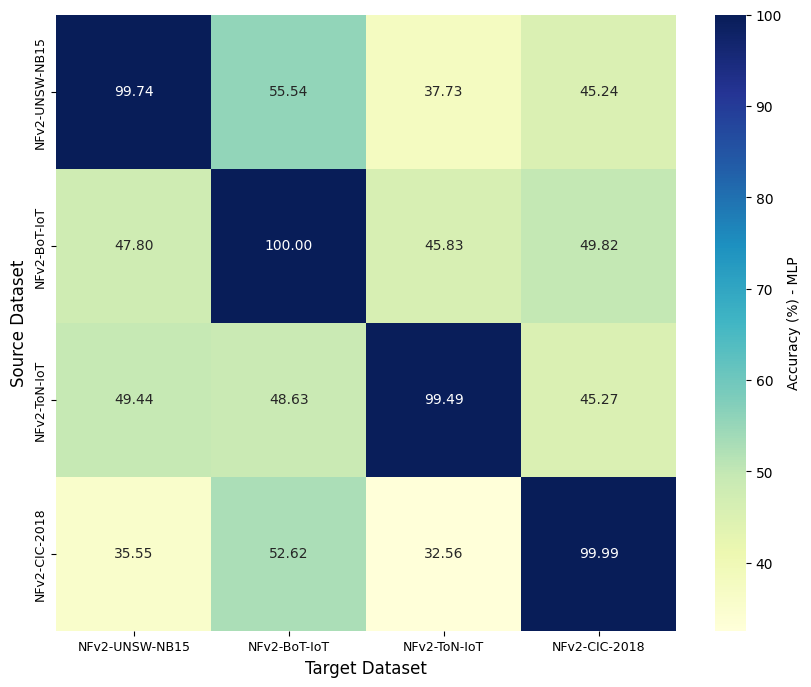

In [5]:
# Plot Confusion Matrix for accuracy
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
        acc_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu", 
        cbar_kws={'label': f'Accuracy (%) - {used_model}'}
    )

ax.set_xlabel("Target Dataset", fontsize=12)
ax.set_ylabel("Source Dataset", fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=90, fontsize=9)
save_path = os.path.join(save_dir, f"{used_model}_Accuracy_Matrix.png")
plt.savefig(save_path, dpi=600)
plt.show()

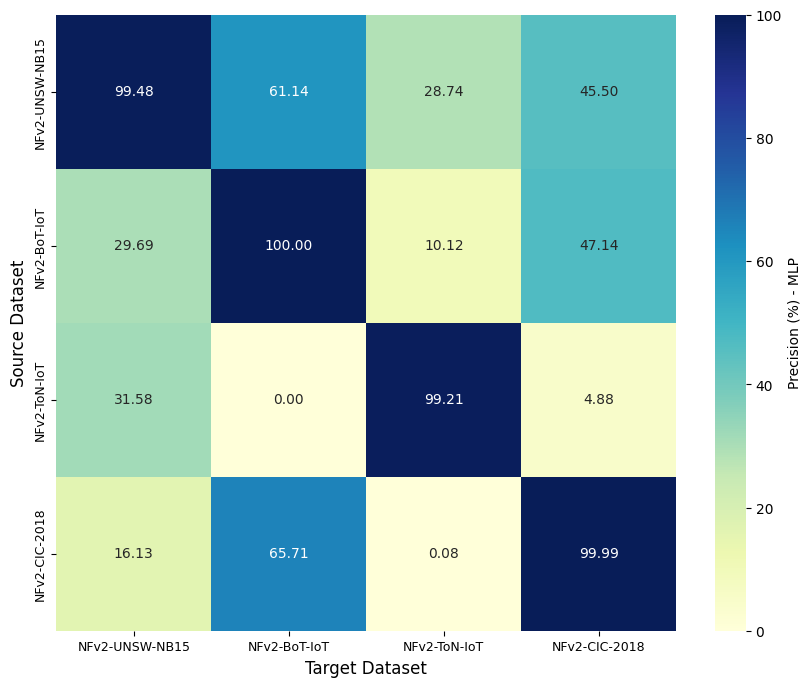

In [6]:
# Plot Confusion Matrix for Precision
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
        prec_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu", 
        cbar_kws={'label': f'Precision (%) - {used_model}'}
    )

ax.set_xlabel("Target Dataset", fontsize=12)
ax.set_ylabel("Source Dataset", fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=90, fontsize=9)

save_path = os.path.join(save_dir, f"{used_model}_Precision_Matrix.png")
plt.savefig(save_path, dpi=600)
plt.show()

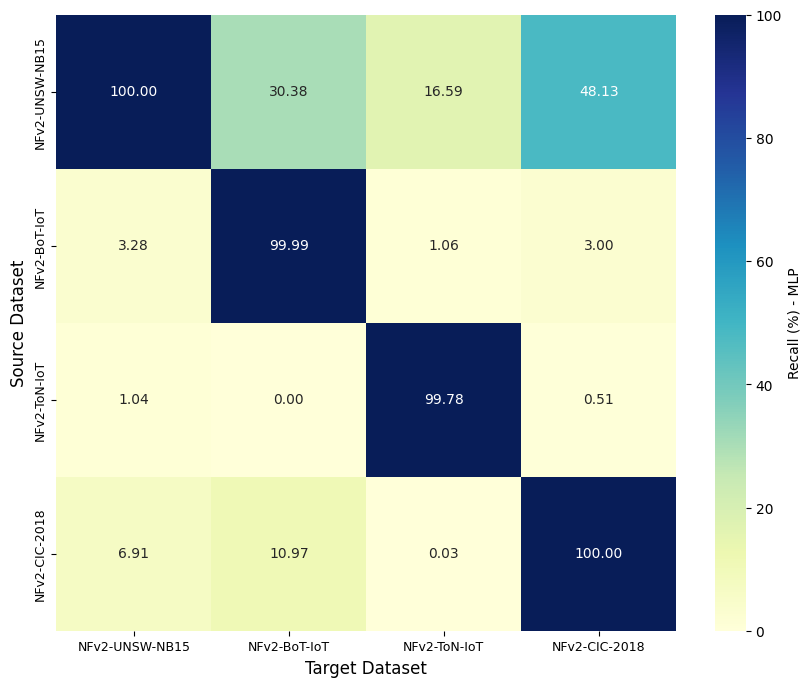

In [7]:
# Plot Confusion Matrix for recall
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
        rec_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu", 
        cbar_kws={'label': f'Recall (%) - {used_model}'}
    )

ax.set_xlabel("Target Dataset", fontsize=12)
ax.set_ylabel("Source Dataset", fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=90, fontsize=9)

save_path = os.path.join(save_dir, f"{used_model}_Recall_Matrix.png")
plt.savefig(save_path, dpi=600)
plt.show()

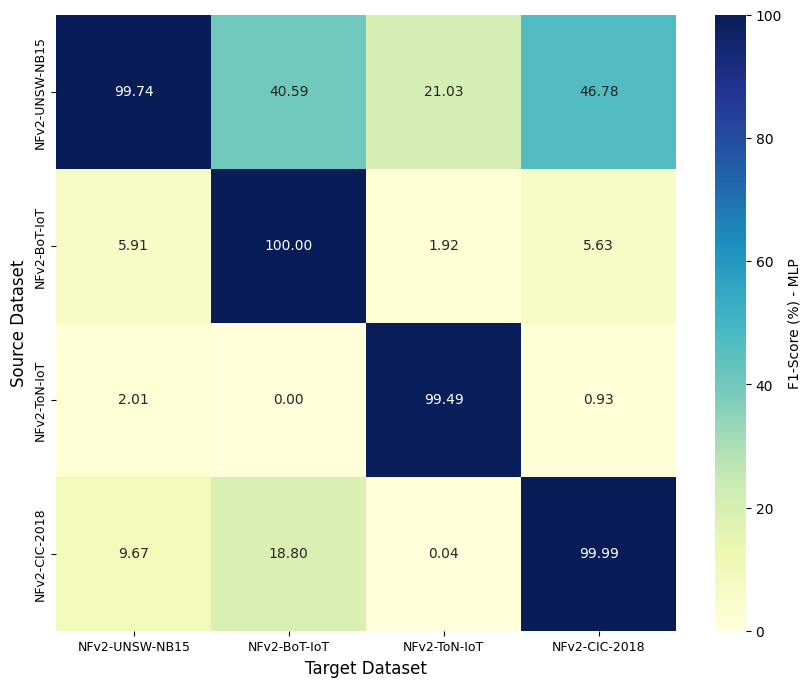

In [8]:
# Plot Confusion Matrix for f1
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
        f1_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu", 
        cbar_kws={'label': f'F1-Score (%) - {used_model}'}
    )

ax.set_xlabel("Target Dataset", fontsize=12)
ax.set_ylabel("Source Dataset", fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=90, fontsize=9)

save_path = os.path.join(save_dir, f"{used_model}_F1_Matrix.png")
plt.savefig(save_path, dpi=600)
plt.show()

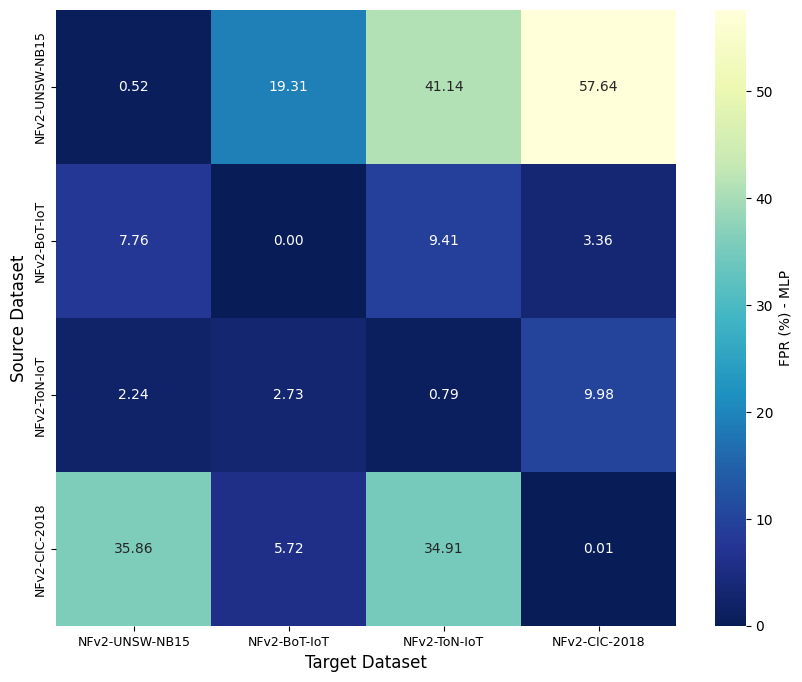

In [9]:
# Plot Confusion Matrix for fpr
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
        fpr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu_r", 
        cbar_kws={'label': f'FPR (%) - {used_model}'}
    )

ax.set_xlabel("Target Dataset", fontsize=12)
ax.set_ylabel("Source Dataset", fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=90, fontsize=9)

save_path = os.path.join(save_dir, f"{used_model}_FPR_Matrix.png")
plt.savefig(save_path, dpi=600)
plt.show()

In [10]:

datasets = f1_matrix.index.tolist()
records = []

for dataset in datasets:
    row_metrics = {
        "Dataset": dataset,
        "In-Domain F1": f1_matrix.loc[dataset, dataset],
        "In-Domain Accuracy": acc_matrix.loc[dataset, dataset],
        "In-Domain Precision": prec_matrix.loc[dataset, dataset],
        "In-Domain Recall": rec_matrix.loc[dataset, dataset],
        "In-Domain FPR": fpr_matrix.loc[dataset, dataset]
    }

    # Get cross-domain values (exclude the diagonal)
    cross_f1 = f1_matrix.loc[dataset].drop(dataset).values
    cross_acc = acc_matrix.loc[dataset].drop(dataset).values
    cross_prec = prec_matrix.loc[dataset].drop(dataset).values
    cross_rec = rec_matrix.loc[dataset].drop(dataset).values
    cross_fpr = fpr_matrix.loc[dataset].drop(dataset).values

    # Add averages
    row_metrics["Avg Cross F1"] = np.mean(cross_f1)
    row_metrics["Avg Cross Accuracy"] = np.mean(cross_acc)
    row_metrics["Avg Cross Precision"] = np.mean(cross_prec)
    row_metrics["Avg Cross Recall"] = np.mean(cross_rec)
    row_metrics["Avg Cross FPR"] = np.mean(cross_fpr)

    # Add decay
    row_metrics["F1 Decay"] = row_metrics["In-Domain F1"] - row_metrics["Avg Cross F1"]
    row_metrics["Accuracy Decay"] = row_metrics["In-Domain Accuracy"] - row_metrics["Avg Cross Accuracy"]
    row_metrics["Precision Decay"] = row_metrics["In-Domain Precision"] - row_metrics["Avg Cross Precision"]
    row_metrics["Recall Decay"] = row_metrics["In-Domain Recall"] - row_metrics["Avg Cross Recall"]
    row_metrics["FPR Increase"] = row_metrics["Avg Cross FPR"] - row_metrics["In-Domain FPR"]

    records.append(row_metrics)

# Convert to DataFrame
summary_df = pd.DataFrame(records).round(2)
summary_df

,Dataset,In-Domain F1,In-Domain Accuracy,In-Domain Precision,In-Domain Recall,In-Domain FPR,Avg Cross F1,Avg Cross Accuracy,Avg Cross Precision,Avg Cross Recall,Avg Cross FPR,F1 Decay,Accuracy Decay,Precision Decay,Recall Decay,FPR Increase
0,NFv2-UNSW-NB15,99.74,99.74,99.48,100.00,0.52,36.13,46.17,45.13,31.70,39.36,63.61,53.57,54.35,68.30,38.84
1,NFv2-BoT-IoT,100.00,100.00,100.00,99.99,0.00,4.49,47.82,28.98,2.45,6.84,95.51,52.18,71.02,97.54,6.84
2,NFv2-ToN-IoT,99.49,99.49,99.21,99.78,0.79,0.98,47.78,12.15,0.52,4.98,98.51,51.71,87.06,99.26,4.19
3,NFv2-CIC-2018,99.99,99.99,99.99,100.00,0.01,9.50,40.24,27.31,5.97,25.50,90.49,59.75,72.68,94.03,25.49


In [11]:
excel_path = os.path.join(save_dir, f"{used_model}_CrossDomain_Evaluation_Summary.xlsx")
csv_path = os.path.join(save_dir, f"{used_model}_CrossDomain_Evaluation_Summary.csv")
# Save as Excel
summary_df.to_excel(excel_path, index=False)

# Or save as CSV
summary_df.to_csv(csv_path, index=False)

print("✅ Summary saved successfully.")

✅ Summary saved successfully.
